# Retail & Marketing Analytics Project
## Notebook 06: Customer Churn Prediction

| | |
|---|---|
| **Project** | Retail & Marketing Analytics - Customer Segmentation & Sales Optimization |
| **Notebook** | 06 - Customer Churn Prediction |
| **Author** | Ayush Kumar Singh |
| **Date** | 16th July 2026 |

### Objectives
- Define a churn target from existing RFM data
- Build a customer-level feature table without data leakage
- Train and validate a baseline model, Logistic Regression, a hyperparameter-tuned
  Random Forest, and XGBoost
- Evaluate models with metrics appropriate for imbalanced classes (ROC-AUC, precision,
  recall, F1) and select the best performer
- Explain the selected model's predictions with SHAP, at both the global and
  individual-customer level
- Save the trained model and generate churn-risk scores for every customer
- Translate model output into a business recommendation (revenue at risk)

### Note on Data Leakage
This notebook predicts churn using **Recency** as the label definition. Because of that,
`Recency`, `R_Score`, `RFM_Score`, `RFM_Score_Numeric`, `Customer_Segment`, `Cluster`, and
`Cluster_Name` (all derived from Recency in Notebook 04) are intentionally **excluded** from
the feature set. Only Frequency, Monetary, and independently engineered behavioral features
are used as predictors, so the model is actually learning to predict churn from behavior
rather than reading it directly off the label.


## 1. Import Libraries and Load Data
Load the cleaned transaction data (Notebook 02) and the RFM / CLV outputs (Notebook 04),
which together provide everything needed to build a churn model without recomputing
earlier steps.

In [1]:
import sys
!{sys.executable} -m pip install xgboost shap

  Using cached xgboost-3.2.0-py3-none-macosx_12_0_arm64.whl.metadata (2.1 kB)
  Using cached shap-0.51.0-cp311-cp311-macosx_11_0_arm64.whl.metadata (25 kB)
  Using cached slicer-0.0.8-py3-none-any.whl.metadata (4.0 kB)
  Using cached numba-0.66.0-cp311-cp311-macosx_12_0_arm64.whl.metadata (2.7 kB)
  Using cached llvmlite-0.48.0-cp311-cp311-macosx_12_0_arm64.whl.metadata (5.0 kB)
  Using cached cloudpickle-3.1.2-py3-none-any.whl.metadata (7.1 kB)
Using cached xgboost-3.2.0-py3-none-macosx_12_0_arm64.whl (2.3 MB)
Using cached shap-0.51.0-cp311-cp311-macosx_11_0_arm64.whl (562 kB)
Using cached slicer-0.0.8-py3-none-any.whl (15 kB)
Using cached cloudpickle-3.1.2-py3-none-any.whl (22 kB)
Using cached llvmlite-0.48.0-cp311-cp311-macosx_12_0_arm64.whl (40.5 MB)
Using cached numba-0.66.0-cp311-cp311-macosx_12_0_arm64.whl (2.7 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [shap]4/6 [numba]t]]


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import (train_test_split, cross_val_score,
                                      StratifiedKFold, RandomizedSearchCV)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (roc_auc_score, roc_curve, confusion_matrix,
                              classification_report, precision_recall_fscore_support)
import xgboost as xgb
import shap
import joblib

DATA_PROCESSED = Path('../data/processed')
FIGURES = Path('../outputs/figures')
REPORTS = Path('../outputs/reports')
MODELS = Path('../outputs/models')

FIGURES.mkdir(parents=True, exist_ok=True)
REPORTS.mkdir(parents=True, exist_ok=True)
MODELS.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(DATA_PROCESSED / 'cleaned_retail_sales.csv')
df['Order_Date'] = pd.to_datetime(df['Order_Date'])

rfm = pd.read_csv(DATA_PROCESSED / 'rfm_analysis.csv')
clv = pd.read_csv(DATA_PROCESSED / 'customer_clv.csv')

print("="*80)
print("CUSTOMER CHURN PREDICTION")
print("="*80)
print(f"\nTransactions: {df.shape}")
print(f"RFM records: {rfm.shape}")
print(f"CLV records: {clv.shape}")

CUSTOMER CHURN PREDICTION

Transactions: (10000, 45)
RFM records: (1986, 10)
CLV records: (1986, 10)


## 2. Define the Churn Target
A customer is labeled **churned (1)** if their Recency (days since last purchase) exceeds
180 days, and **active (0)** otherwise. This threshold matches the churn definition already
used in Notebook 05's KPI report, keeping the two notebooks consistent.

In [3]:
CHURN_THRESHOLD_DAYS = 180
rfm['Churned'] = (rfm['Recency'] > CHURN_THRESHOLD_DAYS).astype(int)

churn_counts = rfm['Churned'].value_counts()
churn_rate = rfm['Churned'].mean() * 100

print(f"Churn threshold: > {CHURN_THRESHOLD_DAYS} days since last purchase")
print(f"\nClass balance:\n{churn_counts}")
print(f"\nOverall churn rate: {churn_rate:.2f}%")

Churn threshold: > 180 days since last purchase

Class balance:
Churned
0    1750
1     236
Name: count, dtype: int64

Overall churn rate: 11.88%


Saved: 28_churn_class_balance.png


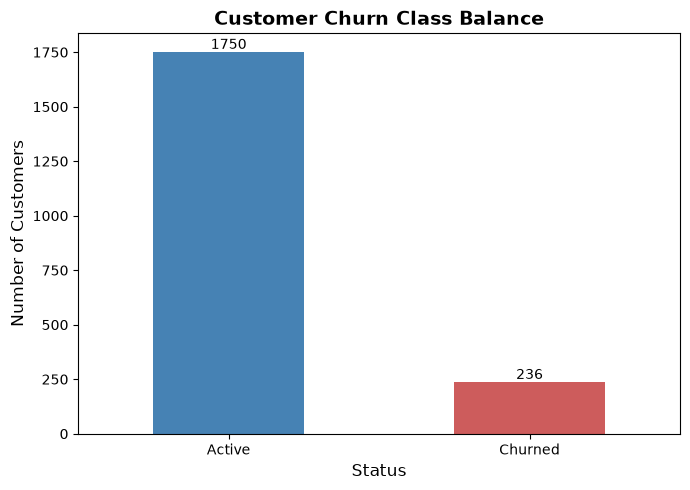


Note: the class imbalance above is why accuracy alone will be a misleading
metric for this model - a classifier that always predicts 'Active' would already
score 88.1% accuracy without learning anything useful.


In [4]:
fig, ax = plt.subplots(figsize=(7, 5))
churn_counts.rename({0: 'Active', 1: 'Churned'}).plot(kind='bar', ax=ax,
                                                        color=['steelblue', 'indianred'])
ax.set_title('Customer Churn Class Balance', fontsize=14, fontweight='bold')
ax.set_xlabel('Status', fontsize=12)
ax.set_ylabel('Number of Customers', fontsize=12)
ax.set_xticklabels(['Active', 'Churned'], rotation=0)
for i, v in enumerate(churn_counts.values):
    ax.text(i, v, str(v), ha='center', va='bottom')
plt.tight_layout()
plt.savefig(FIGURES / '28_churn_class_balance.png', dpi=300, bbox_inches='tight')
print("Saved: 28_churn_class_balance.png")
plt.show()

print("\nNote: the class imbalance above is why accuracy alone will be a misleading")
print("metric for this model - a classifier that always predicts 'Active' would already")
print(f"score {(1 - churn_rate/100)*100:.1f}% accuracy without learning anything useful.")

## 3. Build the Customer-Level Feature Table
Aggregate the transaction-level data into one row per customer, then merge in the
non-leaking RFM fields (Frequency, Monetary) and CLV fields. Categorical preferences
(favorite category, region, customer type) are taken as each customer's most frequent
value (mode).

In [5]:
agg_kwargs = {
    'Total_Sales': ('Sales', 'sum'),
    'Total_Orders': ('Order_ID', 'nunique'),
    'Avg_Order_Value': ('Sales', 'mean'),
    'Total_Quantity': ('Quantity', 'sum'),
}
if 'Discount' in df.columns:
    agg_kwargs['Avg_Discount'] = ('Discount', 'mean')
if 'Profit' in df.columns:
    agg_kwargs['Avg_Profit'] = ('Profit', 'mean')
if 'Delivery_Days' in df.columns:
    agg_kwargs['Avg_Delivery_Days'] = ('Delivery_Days', 'mean')
if 'Is_Weekend' in df.columns:
    agg_kwargs['Weekend_Order_Ratio'] = ('Is_Weekend', 'mean')
if 'Product_Category' in df.columns:
    agg_kwargs['Preferred_Category'] = ('Product_Category',
                                         lambda x: x.mode().iloc[0] if not x.mode().empty else 'Unknown')
    agg_kwargs['Unique_Categories'] = ('Product_Category', 'nunique')
if 'Region' in df.columns:
    agg_kwargs['Preferred_Region'] = ('Region',
                                       lambda x: x.mode().iloc[0] if not x.mode().empty else 'Unknown')
if 'Segment' in df.columns:
    agg_kwargs['Customer_Type'] = ('Segment',
                                    lambda x: x.mode().iloc[0] if not x.mode().empty else 'Unknown')

customer_features = df.groupby('Customer_ID').agg(**agg_kwargs).reset_index()
print(f"Customer-level feature table: {customer_features.shape[0]:,} customers, "
      f"{customer_features.shape[1]} raw columns")
print(customer_features.head())

Customer-level feature table: 1,986 customers, 13 raw columns
  Customer_ID  Total_Sales  Total_Orders  Avg_Order_Value  Total_Quantity  \
0    CUST0001   943.770842             8       117.971355              39   
1    CUST0002   617.531725             6       102.921954              29   
2    CUST0003   548.860692             5       109.772138              24   
3    CUST0004   247.117878             3        82.372626              17   
4    CUST0005   337.341185             4        84.335296              31   

   Avg_Discount  Avg_Profit  Avg_Delivery_Days  Weekend_Order_Ratio  \
0      0.112500   29.680520                1.0             0.500000   
1      0.116667   43.548708                1.0             0.333333   
2      0.050000   36.878440                1.0             0.400000   
3      0.000000   14.221973                1.0             0.333333   
4      0.062500    3.269442                1.0             0.250000   

  Preferred_Category  Unique_Categories Preferre

In [6]:
customer_features = customer_features.merge(
    rfm[['Customer_ID', 'Frequency', 'Monetary', 'Churned']],
    on='Customer_ID', how='left'
)
clv_cols = [c for c in ['Customer_ID', 'CLV_Simple', 'CLV_Category',
                         'Purchase_Frequency', 'Lifespan_Days'] if c in clv.columns]
customer_features = customer_features.merge(clv[clv_cols], on='Customer_ID', how='left')

print(f"Merged feature table shape: {customer_features.shape}")
print("\nMissing values per column:")
print(customer_features.isnull().sum())

Merged feature table shape: (1986, 20)

Missing values per column:
Customer_ID            0
Total_Sales            0
Total_Orders           0
Avg_Order_Value        0
Total_Quantity         0
Avg_Discount           0
Avg_Profit             1
Avg_Delivery_Days      0
Weekend_Order_Ratio    0
Preferred_Category     0
Unique_Categories      0
Preferred_Region       0
Customer_Type          0
Frequency              0
Monetary               0
Churned                0
CLV_Simple             0
CLV_Category           0
Purchase_Frequency     0
Lifespan_Days          0
dtype: int64


In [7]:
customer_features = customer_features.dropna(subset=['Churned'])
customer_features['Churned'] = customer_features['Churned'].astype(int)

numeric_cols_fill = customer_features.select_dtypes(include=[np.number]).columns
customer_features[numeric_cols_fill] = customer_features[numeric_cols_fill].fillna(
    customer_features[numeric_cols_fill].median()
)

categorical_features = [c for c in ['Preferred_Category', 'Preferred_Region',
                                     'Customer_Type', 'CLV_Category']
                         if c in customer_features.columns]
for c in categorical_features:
    customer_features[c] = customer_features[c].fillna('Unknown').astype(str)

print(f"Final feature table: {customer_features.shape[0]:,} customers, "
      f"{customer_features.shape[1]} columns")
print(f"Categorical features: {categorical_features}")

customer_features.to_csv(DATA_PROCESSED / 'churn_features.csv', index=False)
print("\nSaved: data/processed/churn_features.csv")

Final feature table: 1,986 customers, 20 columns
Categorical features: ['Preferred_Category', 'Preferred_Region', 'Customer_Type', 'CLV_Category']

Saved: data/processed/churn_features.csv


## 4. Explore Churn by Feature
Compare how key behavioral metrics differ between active and churned customers.

Saved: 29_churn_feature_comparison.png


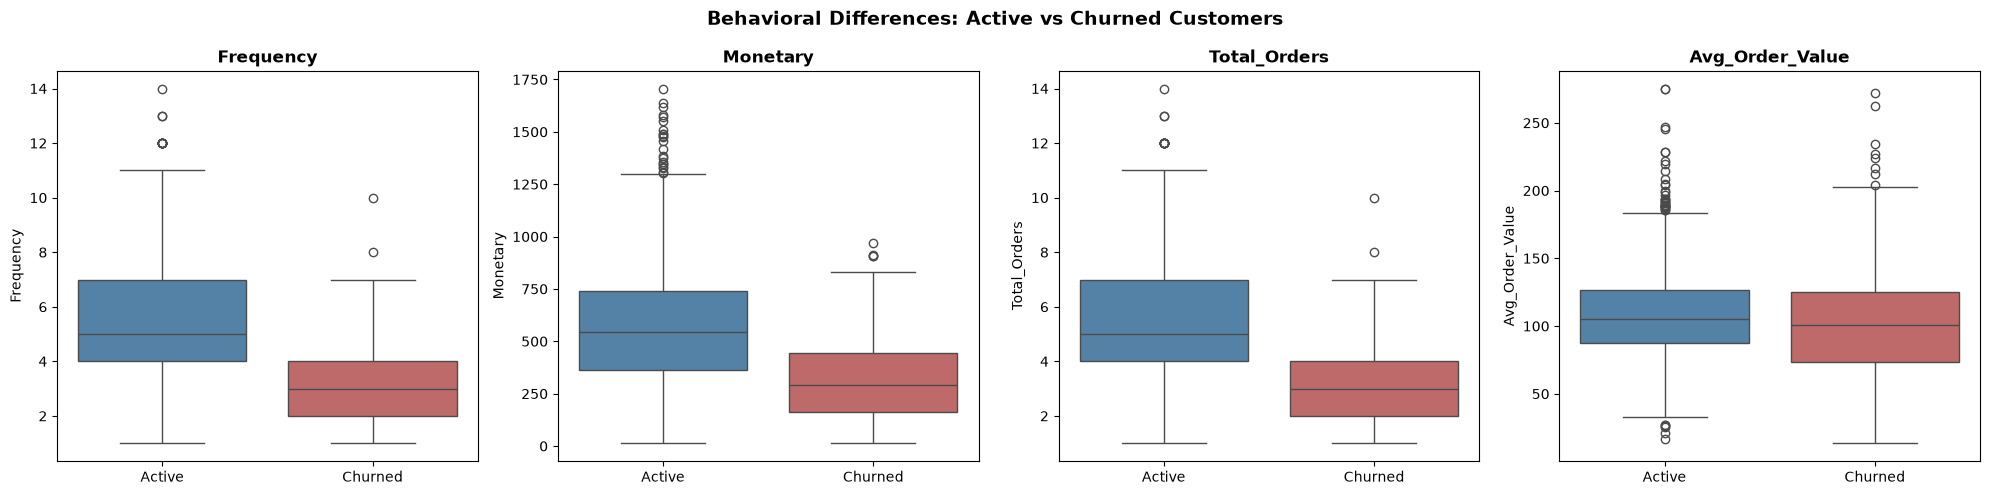

In [8]:
compare_features = [c for c in ['Frequency', 'Monetary', 'Total_Orders', 'Avg_Order_Value']
                     if c in customer_features.columns]

fig, axes = plt.subplots(1, len(compare_features), figsize=(5*len(compare_features), 5))
if len(compare_features) == 1:
    axes = [axes]
for idx, feat in enumerate(compare_features):
    sns.boxplot(data=customer_features, x='Churned', y=feat, ax=axes[idx],
                palette=['steelblue', 'indianred'])
    axes[idx].set_xticklabels(['Active', 'Churned'])
    axes[idx].set_title(feat, fontweight='bold')
    axes[idx].set_xlabel('')
plt.suptitle('Behavioral Differences: Active vs Churned Customers', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES / '29_churn_feature_comparison.png', dpi=300, bbox_inches='tight')
print("Saved: 29_churn_feature_comparison.png")
plt.show()

## 5. Feature Encoding and Train-Test Split
One-hot encode categorical features, split into train/test sets with stratification,
and scale numeric features.

In [9]:
X = customer_features.drop(columns=['Customer_ID', 'Churned'], errors='ignore')
y = customer_features['Churned']

X_encoded = pd.get_dummies(X, columns=categorical_features, drop_first=True)
print(f"Feature matrix after encoding: {X_encoded.shape}")

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.25, random_state=42, stratify=y
)
print(f"\nTrain set: {X_train.shape}, Test set: {X_test.shape}")
print(f"Train churn rate: {y_train.mean()*100:.2f}%, Test churn rate: {y_test.mean()*100:.2f}%")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("\nFeatures scaled with StandardScaler")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

Feature matrix after encoding: (1986, 25)

Train set: (1489, 25), Test set: (497, 25)
Train churn rate: 11.89%, Test churn rate: 11.87%

Features scaled with StandardScaler


## 6. Baseline Model
Establish what a trivial baseline (always predicting the majority class) achieves, since
accuracy alone is misleading on imbalanced data.

In [10]:
baseline = DummyClassifier(strategy='most_frequent', random_state=42)
baseline.fit(X_train_scaled, y_train)
baseline_pred = baseline.predict(X_test_scaled)
baseline_accuracy = (baseline_pred == y_test).mean()

print("BASELINE MODEL (always predicts majority class)")
print(f"Accuracy: {baseline_accuracy:.4f}")
print("This is a reference point only - it never identifies a churned customer.")

BASELINE MODEL (always predicts majority class)
Accuracy: 0.8813
This is a reference point only - it never identifies a churned customer.


## 7. Logistic Regression
An interpretable baseline classifier, cross-validated with ROC-AUC (appropriate for
imbalanced classification) and evaluated on the held-out test set.

In [11]:
log_reg = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
log_cv_scores = cross_val_score(log_reg, X_train_scaled, y_train, cv=cv, scoring='roc_auc')
print("LOGISTIC REGRESSION")
print(f"Cross-validated ROC-AUC: {log_cv_scores.mean():.4f} (+/- {log_cv_scores.std():.4f})")

log_reg.fit(X_train_scaled, y_train)
log_pred = log_reg.predict(X_test_scaled)
log_proba = log_reg.predict_proba(X_test_scaled)[:, 1]
log_test_auc = roc_auc_score(y_test, log_proba)

print(f"\nTest set ROC-AUC: {log_test_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, log_pred, target_names=['Active', 'Churned']))

LOGISTIC REGRESSION
Cross-validated ROC-AUC: 0.9042 (+/- 0.0135)

Test set ROC-AUC: 0.9068

Classification Report:
              precision    recall  f1-score   support

      Active       0.98      0.79      0.88       438
     Churned       0.36      0.86      0.51        59

    accuracy                           0.80       497
   macro avg       0.67      0.83      0.69       497
weighted avg       0.90      0.80      0.83       497



## 8. Random Forest with Hyperparameter Tuning
Rather than using default parameters, search over a range of Random Forest hyperparameters
with `RandomizedSearchCV` (20 random combinations, 5-fold cross-validation, scored on
ROC-AUC). This is more efficient than an exhaustive grid search while still covering the
key parameters that affect model performance and overfitting.

In [12]:
rf_param_distributions = {
    'n_estimators': [100, 200, 300, 400],
    'max_depth': [4, 6, 8, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None],
}

rf_base = RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1)

rf_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=rf_param_distributions,
    n_iter=20,
    scoring='roc_auc',
    cv=cv,
    random_state=42,
    n_jobs=-1
)

rf_search.fit(X_train_scaled, y_train)

print("RANDOM FOREST - HYPERPARAMETER TUNING")
print(f"Best cross-validated ROC-AUC: {rf_search.best_score_:.4f}")
print(f"Best parameters: {rf_search.best_params_}")

rf_tuned = rf_search.best_estimator_
rf_pred = rf_tuned.predict(X_test_scaled)
rf_proba = rf_tuned.predict_proba(X_test_scaled)[:, 1]
rf_test_auc = roc_auc_score(y_test, rf_proba)

print(f"\nTest set ROC-AUC (tuned): {rf_test_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, rf_pred, target_names=['Active', 'Churned']))

RANDOM FOREST - HYPERPARAMETER TUNING
Best cross-validated ROC-AUC: 0.9359
Best parameters: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': None, 'max_depth': None}

Test set ROC-AUC (tuned): 0.9510

Classification Report:
              precision    recall  f1-score   support

      Active       0.99      0.89      0.94       438
     Churned       0.53      0.93      0.67        59

    accuracy                           0.89       497
   macro avg       0.76      0.91      0.81       497
weighted avg       0.94      0.89      0.91       497



## 9. XGBoost
Train a gradient-boosted tree model, which often outperforms Random Forest on tabular
data by building trees sequentially to correct previous errors. `scale_pos_weight`
compensates for the churn class being the minority, similar to `class_weight='balanced'`
in the other models.

In [13]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

xgb_cv_scores = cross_val_score(xgb_model, X_train_scaled, y_train, cv=cv, scoring='roc_auc')
print("XGBOOST")
print(f"Cross-validated ROC-AUC: {xgb_cv_scores.mean():.4f} (+/- {xgb_cv_scores.std():.4f})")

xgb_model.fit(X_train_scaled, y_train)
xgb_pred = xgb_model.predict(X_test_scaled)
xgb_proba = xgb_model.predict_proba(X_test_scaled)[:, 1]
xgb_test_auc = roc_auc_score(y_test, xgb_proba)

print(f"\nTest set ROC-AUC: {xgb_test_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, xgb_pred, target_names=['Active', 'Churned']))

XGBOOST
Cross-validated ROC-AUC: 0.9376 (+/- 0.0092)

Test set ROC-AUC: 0.9461

Classification Report:
              precision    recall  f1-score   support

      Active       0.97      0.92      0.94       438
     Churned       0.55      0.78      0.65        59

    accuracy                           0.90       497
   macro avg       0.76      0.85      0.79       497
weighted avg       0.92      0.90      0.91       497



## 10. Model Comparison and Selection
Compare all trained models on test-set ROC-AUC and select the best performer as the
final model used for explainability, saving, and scoring.

In [14]:
model_comparison = pd.DataFrame({
    'Model': ['Baseline (majority class)', 'Logistic Regression', 'Random Forest (tuned)', 'XGBoost'],
    'Test_ROC_AUC': [np.nan, log_test_auc, rf_test_auc, xgb_test_auc],
    'CV_ROC_AUC_Mean': [np.nan, log_cv_scores.mean(), rf_search.best_score_, xgb_cv_scores.mean()],
}).round(4)

print("MODEL COMPARISON")
print(model_comparison)

candidates = {
    'Logistic Regression': (log_reg, log_test_auc, log_proba, log_pred),
    'Random Forest (tuned)': (rf_tuned, rf_test_auc, rf_proba, rf_pred),
    'XGBoost': (xgb_model, xgb_test_auc, xgb_proba, xgb_pred),
}

best_model_name = max(candidates, key=lambda k: candidates[k][1])
final_model, final_test_auc, final_proba, final_pred = candidates[best_model_name]

print(f"\nSelected model: {best_model_name} (Test ROC-AUC = {final_test_auc:.4f})")

MODEL COMPARISON
                       Model  Test_ROC_AUC  CV_ROC_AUC_Mean
0  Baseline (majority class)           NaN              NaN
1        Logistic Regression        0.9068           0.9042
2      Random Forest (tuned)        0.9510           0.9359
3                    XGBoost        0.9461           0.9376

Selected model: Random Forest (tuned) (Test ROC-AUC = 0.9510)


Saved: 30_roc_curve_comparison.png


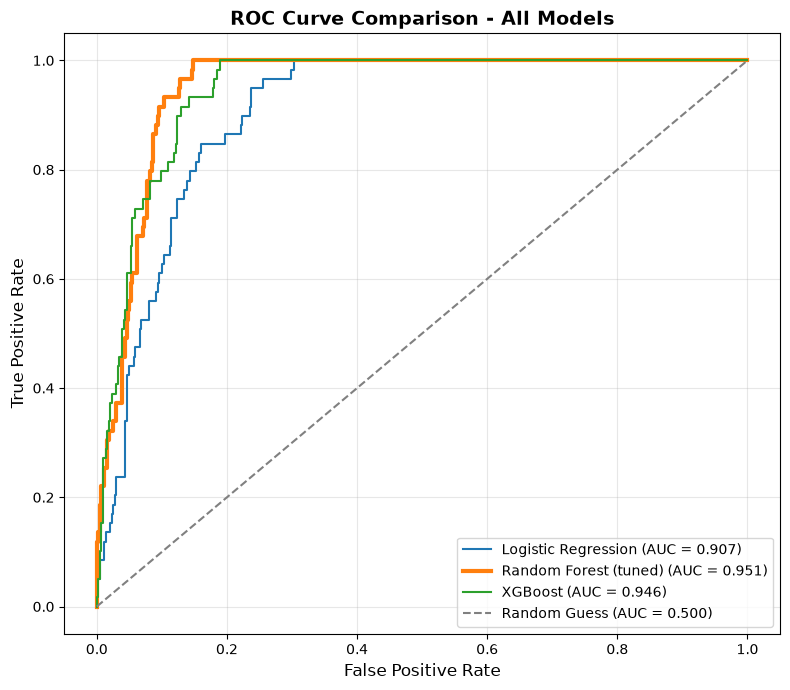

In [15]:
fig, ax = plt.subplots(figsize=(8, 7))
for name, (mdl, auc_score, proba, pred) in candidates.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    linewidth = 3 if name == best_model_name else 1.5
    ax.plot(fpr, tpr, label=f'{name} (AUC = {auc_score:.3f})', linewidth=linewidth)
ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Guess (AUC = 0.500)')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve Comparison - All Models', fontsize=14, fontweight='bold')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES / '30_roc_curve_comparison.png', dpi=300, bbox_inches='tight')
print("Saved: 30_roc_curve_comparison.png")
plt.show()

## 11. Confusion Matrix (Selected Model)
Inspect exactly how many churned customers the selected model correctly flags versus
misses on the held-out test set.

Saved: 31_confusion_matrix.png


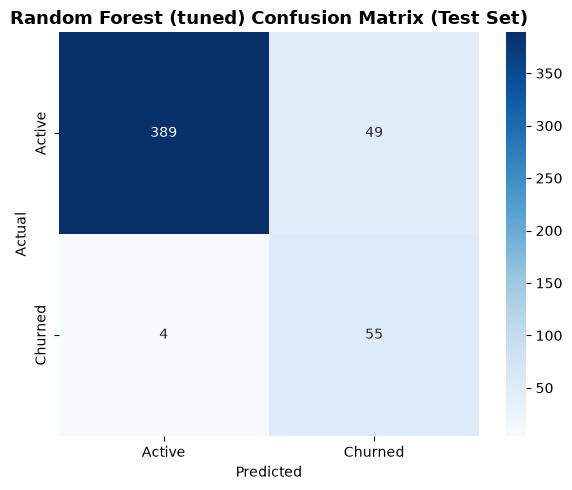


True Negatives: 389  False Positives: 49
False Negatives: 4  True Positives: 55

Of 59 actually churned customers, the model correctly identified 55 (93.2% recall).


In [16]:
cm = confusion_matrix(y_test, final_pred)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Active', 'Churned'], yticklabels=['Active', 'Churned'], ax=ax)
ax.set_title(f'{best_model_name} Confusion Matrix (Test Set)', fontsize=13, fontweight='bold')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig(FIGURES / '31_confusion_matrix.png', dpi=300, bbox_inches='tight')
print("Saved: 31_confusion_matrix.png")
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"\nTrue Negatives: {tn}  False Positives: {fp}")
print(f"False Negatives: {fn}  True Positives: {tp}")
print(f"\nOf {tp + fn} actually churned customers, the model correctly identified {tp} "
      f"({tp/(tp+fn)*100:.1f}% recall).")

## 12. Feature Importance (Selected Model)
Identify which behavioral features drive the selected model's churn predictions most,
connecting the model back to the RFM story from Notebook 04.

Saved: 32_feature_importance.png


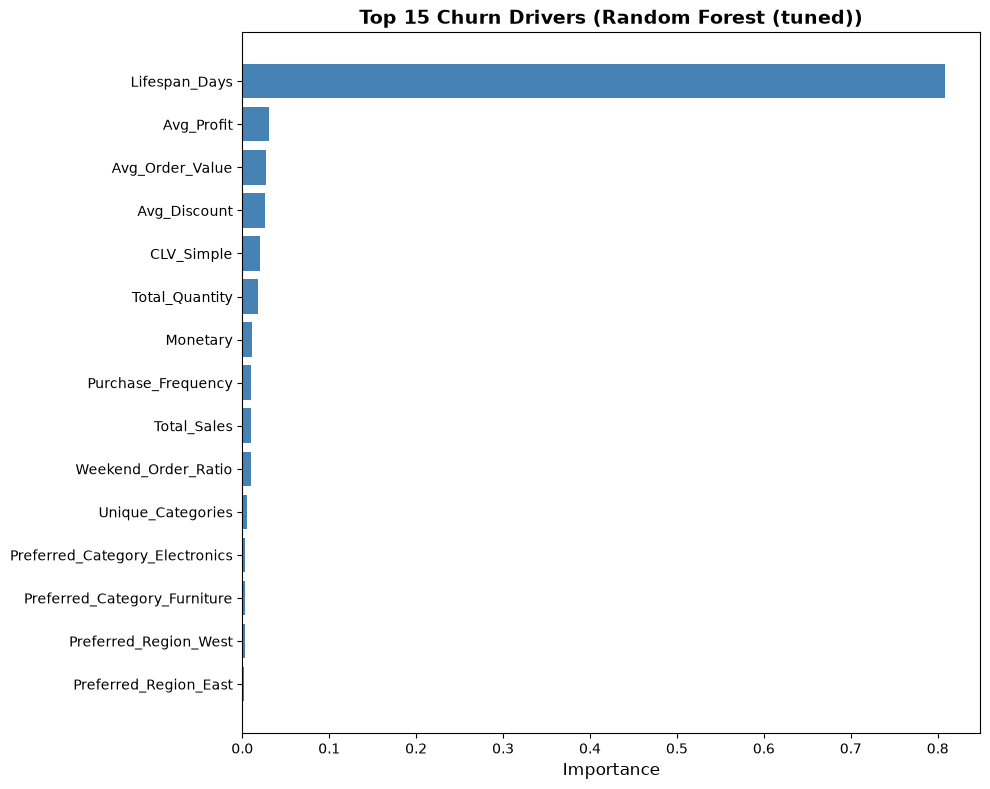


Top 10 Churn Drivers:
            Feature  Importance
      Lifespan_Days    0.808224
         Avg_Profit    0.030559
    Avg_Order_Value    0.027120
       Avg_Discount    0.026392
         CLV_Simple    0.019841
     Total_Quantity    0.017956
           Monetary    0.010614
 Purchase_Frequency    0.010318
        Total_Sales    0.010235
Weekend_Order_Ratio    0.009487


In [17]:
if hasattr(final_model, 'feature_importances_'):
    importances = pd.DataFrame({
        'Feature': X_encoded.columns,
        'Importance': final_model.feature_importances_
    }).sort_values('Importance', ascending=False).head(15)
else:
    # Logistic Regression - use absolute coefficient magnitude
    importances = pd.DataFrame({
        'Feature': X_encoded.columns,
        'Importance': np.abs(final_model.coef_[0])
    }).sort_values('Importance', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(importances['Feature'][::-1], importances['Importance'][::-1], color='steelblue')
ax.set_title(f'Top 15 Churn Drivers ({best_model_name})', fontsize=14, fontweight='bold')
ax.set_xlabel('Importance', fontsize=12)
plt.tight_layout()
plt.savefig(FIGURES / '32_feature_importance.png', dpi=300, bbox_inches='tight')
print("Saved: 32_feature_importance.png")
plt.show()

print("\nTop 10 Churn Drivers:")
print(importances.head(10).to_string(index=False))

## 13. SHAP Explainability
Feature importance shows which features matter *on average* across all customers. SHAP
(SHapley Additive exPlanations) goes further: it explains *how* each feature pushed each
*individual* customer's prediction up or down. This is the standard tool for explaining
tree-based model decisions to non-technical stakeholders.

In [18]:
X_test_df = pd.DataFrame(X_test_scaled, columns=X_encoded.columns)

if best_model_name == 'Logistic Regression':
    explainer = shap.LinearExplainer(final_model, X_train_scaled)
else:
    explainer = shap.TreeExplainer(final_model)

shap_explanation = explainer(X_test_df)

# Normalize to a 2D (samples, features) explanation for the positive (churned) class,
# since tree explainers on RandomForestClassifier return one set of values per class.
shap_values = shap_explanation.values
if shap_values.ndim == 3:
    shap_values_pos = shap_values[:, :, 1]
    base_value = shap_explanation.base_values[:, 1] if np.ndim(shap_explanation.base_values) > 1 \
        else shap_explanation.base_values
else:
    shap_values_pos = shap_values
    base_value = shap_explanation.base_values

shap_exp_pos = shap.Explanation(
    values=shap_values_pos,
    base_values=base_value,
    data=shap_explanation.data,
    feature_names=X_encoded.columns.tolist()
)

print(f"SHAP values computed for {shap_values_pos.shape[0]} test customers "
      f"across {shap_values_pos.shape[1]} features using {best_model_name}.")

SHAP values computed for 497 test customers across 25 features using Random Forest (tuned).


Saved: 33_shap_global_importance.png


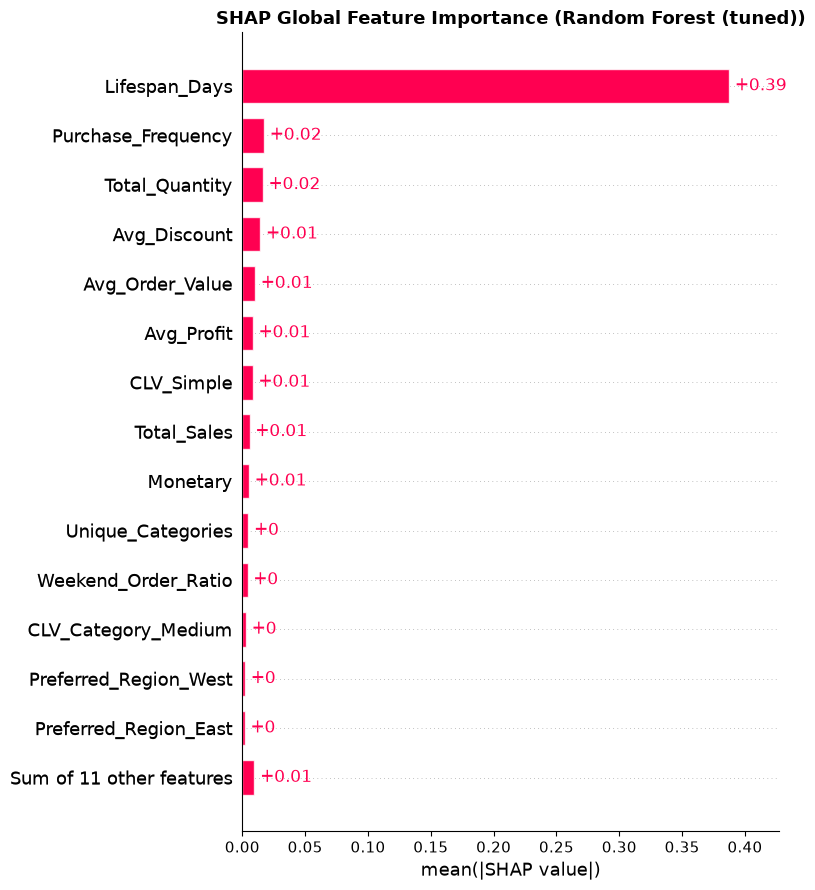

In [19]:
# Global explanation: which features matter most across all customers
plt.figure(figsize=(10, 8))
shap.plots.bar(shap_exp_pos, show=False, max_display=15)
plt.title(f'SHAP Global Feature Importance ({best_model_name})', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES / '33_shap_global_importance.png', dpi=300, bbox_inches='tight')
print("Saved: 33_shap_global_importance.png")
plt.show()

In [20]:
# Individual explanations: how the model reasoned about 5 specific customers
n_samples_to_explain = min(5, len(shap_exp_pos))

for i in range(n_samples_to_explain):
    plt.figure(figsize=(10, 6))
    shap.plots.waterfall(shap_exp_pos[i], show=False, max_display=10)
    plt.title(f'SHAP Explanation - Test Customer {i+1}', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(FIGURES / f'34_shap_waterfall_customer_{i+1}.png', dpi=300, bbox_inches='tight')
    plt.close()

print(f"Saved {n_samples_to_explain} individual SHAP waterfall plots "
      f"(34_shap_waterfall_customer_1.png ... {n_samples_to_explain}.png)")
print("\nEach waterfall plot shows how the model moved from its baseline churn probability")
print("to that specific customer's predicted probability, feature by feature.")

Saved 5 individual SHAP waterfall plots (34_shap_waterfall_customer_1.png ... 5.png)

Each waterfall plot shows how the model moved from its baseline churn probability
to that specific customer's predicted probability, feature by feature.


## 14. Save the Model and Generate Churn-Risk Scores
Persist the selected model, the fitted scaler, and the exact feature column order so it
can be reloaded without retraining. Then score every customer in the dataset with a
churn probability.

In [21]:
joblib.dump(final_model, MODELS / 'churn_model_best.pkl')
joblib.dump(scaler, MODELS / 'churn_scaler.pkl')
joblib.dump(list(X_encoded.columns), MODELS / 'churn_feature_columns.pkl')

with open(MODELS / 'churn_model_info.txt', 'w') as f:
    f.write(f"Selected model: {best_model_name}\n")
    f.write(f"Test ROC-AUC: {final_test_auc:.4f}\n")
    f.write(f"Saved: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}\n")

print("Saved model artifacts:")
print(f"  {MODELS / 'churn_model_best.pkl'} ({best_model_name})")
print(f"  {MODELS / 'churn_scaler.pkl'}")
print(f"  {MODELS / 'churn_feature_columns.pkl'}")

Saved model artifacts:
  ../outputs/models/churn_model_best.pkl (Random Forest (tuned))
  ../outputs/models/churn_scaler.pkl
  ../outputs/models/churn_feature_columns.pkl


In [22]:
all_proba = final_model.predict_proba(scaler.transform(X_encoded))[:, 1]

churn_predictions = customer_features[['Customer_ID', 'Total_Sales']].copy()
churn_predictions['Churn_Probability'] = all_proba
churn_predictions['Predicted_Churn'] = (all_proba >= 0.5).astype(int)
churn_predictions['Actual_Churn'] = y.values

if 'CLV_Simple' in customer_features.columns:
    churn_predictions['CLV_Simple'] = customer_features['CLV_Simple'].values

churn_predictions = churn_predictions.sort_values('Churn_Probability', ascending=False)
churn_predictions.to_csv(DATA_PROCESSED / 'churn_predictions.csv', index=False)

print(f"Scored {len(churn_predictions):,} customers using {best_model_name}")
print("Saved: data/processed/churn_predictions.csv")
print("\nHighest risk customers:")
print(churn_predictions.head(10).to_string(index=False))

Scored 1,986 customers using Random Forest (tuned)
Saved: data/processed/churn_predictions.csv

Highest risk customers:
Customer_ID  Total_Sales  Churn_Probability  Predicted_Churn  Actual_Churn  CLV_Simple
   CUST1347   587.367291           0.999545                1             1 3555.843699
   CUST1440   504.286903           0.998831                1             1 3052.886045
   CUST1401   502.670938           0.997708                1             1 3043.103209
   CUST0867   531.173581           0.997375                1             1 3215.654430
   CUST1267   368.105640           0.995736                1             1 4481.686163
   CUST0279   186.875809           0.995500                1             1 1131.321368
   CUST0764   474.692226           0.994861                1             1 4334.533392
   CUST1429   467.950344           0.994113                1             1 4272.971583
   CUST0648   212.715167           0.994085                1             1 1287.749417
   CUST168

## 15. Business Translation: Revenue at Risk
Translate the model's output into a business number: identify the top 20% highest-risk
customers by predicted churn probability, and estimate how much historical revenue they
represent using actual historical sales.

In [23]:
risk_threshold = churn_predictions['Churn_Probability'].quantile(0.80)
high_risk = churn_predictions[churn_predictions['Churn_Probability'] >= risk_threshold]

revenue_at_risk = high_risk['Total_Sales'].sum()
total_revenue = churn_predictions['Total_Sales'].sum()
revenue_at_risk_pct = (revenue_at_risk / total_revenue) * 100

print("="*80)
print("REVENUE AT RISK ANALYSIS")
print("="*80)
print(f"\nSelected model: {best_model_name} (Test ROC-AUC = {final_test_auc:.4f})")
print(f"High-risk threshold (80th percentile churn probability): {risk_threshold:.3f}")
print(f"High-risk customers: {len(high_risk):,} ({len(high_risk)/len(churn_predictions)*100:.1f}% of base)")
print(f"Historical revenue represented: ${revenue_at_risk:,.2f} ({revenue_at_risk_pct:.2f}% of total)")

model_precision, model_recall, model_f1, _ = precision_recall_fscore_support(
    y_test, final_pred, average='binary'
)

business_report = f"""
CHURN PREDICTION MODEL - BUSINESS SUMMARY
{'='*80}

SELECTED MODEL: {best_model_name}
  - Test ROC-AUC: {final_test_auc:.3f}
  - Precision (Churned class): {model_precision:.3f}
  - Recall (Churned class): {model_recall:.3f}
  - F1 Score (Churned class): {model_f1:.3f}
  - Baseline accuracy (majority class): {baseline_accuracy:.3f}

MODEL COMPARISON:
{model_comparison.to_string(index=False)}

CHURN OVERVIEW:
  - Overall churn rate: {churn_rate:.2f}%
  - Churn definition: no purchase in the last {CHURN_THRESHOLD_DAYS} days

REVENUE AT RISK:
  - High-risk customers (top 20% by predicted probability): {len(high_risk):,}
  - Historical revenue represented: ${revenue_at_risk:,.2f} ({revenue_at_risk_pct:.2f}% of total)

TOP CHURN DRIVERS:
{chr(10).join(f"  - {row.Feature}: {row.Importance:.3f}" for row in importances.head(5).itertuples())}

RECOMMENDATION:
  Prioritize retention outreach toward the {len(high_risk):,} customers flagged as
  high-risk. Given the model recall of {model_recall:.1%}, expect some churned customers
  to still be missed - this model should support, not replace, the existing RFM-based
  segmentation from Notebook 04. SHAP explanations for individual customers are available
  in outputs/figures/ for use in retention team conversations.

Report Generated: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}
{'='*80}
"""

with open(REPORTS / 'churn_model_report.txt', 'w') as f:
    f.write(business_report)

print(business_report)
print("Saved: outputs/reports/churn_model_report.txt")
print("\n" + "="*80)
print("NOTEBOOK 06 COMPLETED SUCCESSFULLY!")
print("="*80)

REVENUE AT RISK ANALYSIS

Selected model: Random Forest (tuned) (Test ROC-AUC = 0.9510)
High-risk threshold (80th percentile churn probability): 0.446
High-risk customers: 398 (20.0% of base)
Historical revenue represented: $127,162.08 (11.79% of total)

CHURN PREDICTION MODEL - BUSINESS SUMMARY

SELECTED MODEL: Random Forest (tuned)
  - Test ROC-AUC: 0.951
  - Precision (Churned class): 0.529
  - Recall (Churned class): 0.932
  - F1 Score (Churned class): 0.675
  - Baseline accuracy (majority class): 0.881

MODEL COMPARISON:
                    Model  Test_ROC_AUC  CV_ROC_AUC_Mean
Baseline (majority class)           NaN              NaN
      Logistic Regression        0.9068           0.9042
    Random Forest (tuned)        0.9510           0.9359
                  XGBoost        0.9461           0.9376

CHURN OVERVIEW:
  - Overall churn rate: 11.88%
  - Churn definition: no purchase in the last 180 days

REVENUE AT RISK:
  - High-risk customers (top 20% by predicted probability): 39

---
### Summary

In this notebook we:
- Defined a churn label from Recency while explicitly excluding Recency-derived fields
  from the feature set to avoid data leakage
- Built a customer-level feature table combining transaction aggregates, RFM Frequency/Monetary,
  and CLV metrics
- Established a baseline model, then trained Logistic Regression, a **hyperparameter-tuned**
  Random Forest (via RandomizedSearchCV), and **XGBoost**
- Compared all models on cross-validated and test ROC-AUC, and automatically selected the
  best performer
- Explained the selected model's decisions with **SHAP**, both globally (which features
  matter most overall) and individually (why 5 specific customers were scored as they were)
- Saved the trained model, scaler, and feature schema as reusable artifacts, and scored
  every customer with a churn probability
- Translated the model into a business number: revenue at risk from the top 20%
  highest-risk customers, plus a written recommendation

This extends the project from descriptive customer analytics (Notebooks 01-05) into
explainable, tuned predictive analytics, while staying consistent with the RFM
segmentation already built in Notebook 04.
